In [1]:
#importing Libraries

import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, DataLoader

In [2]:
#Define Transformations

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [3]:
#Load Dataset

dataset_path = r"E:\Laptop\Final_project\Data\PlantVillage"

full_dataset = ImageFolder(root=dataset_path)
print("Classes:", len(full_dataset.classes))
print("Images:", len(full_dataset))

Classes: 15
Images: 20638


In [4]:
#Check Class Distribution

class_names = full_dataset.classes

for i, cls in enumerate(class_names):
    print(i, cls)

0 Pepper__bell___Bacterial_spot
1 Pepper__bell___healthy
2 Potato___Early_blight
3 Potato___Late_blight
4 Potato___healthy
5 Tomato_Bacterial_spot
6 Tomato_Early_blight
7 Tomato_Late_blight
8 Tomato_Leaf_Mold
9 Tomato_Septoria_leaf_spot
10 Tomato_Spider_mites_Two_spotted_spider_mite
11 Tomato__Target_Spot
12 Tomato__Tomato_YellowLeaf__Curl_Virus
13 Tomato__Tomato_mosaic_virus
14 Tomato_healthy


In [5]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

In [6]:
#Split Dataset

dataset_size = len(full_dataset)

train_size = int(0.70 * dataset_size)
val_size = int(0.15 * dataset_size)

test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size]
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

14446
3095
3097


In [7]:
#Transformations

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

In [8]:
#Create Batch Loaders

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [9]:
#Verify Batch Shapes

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


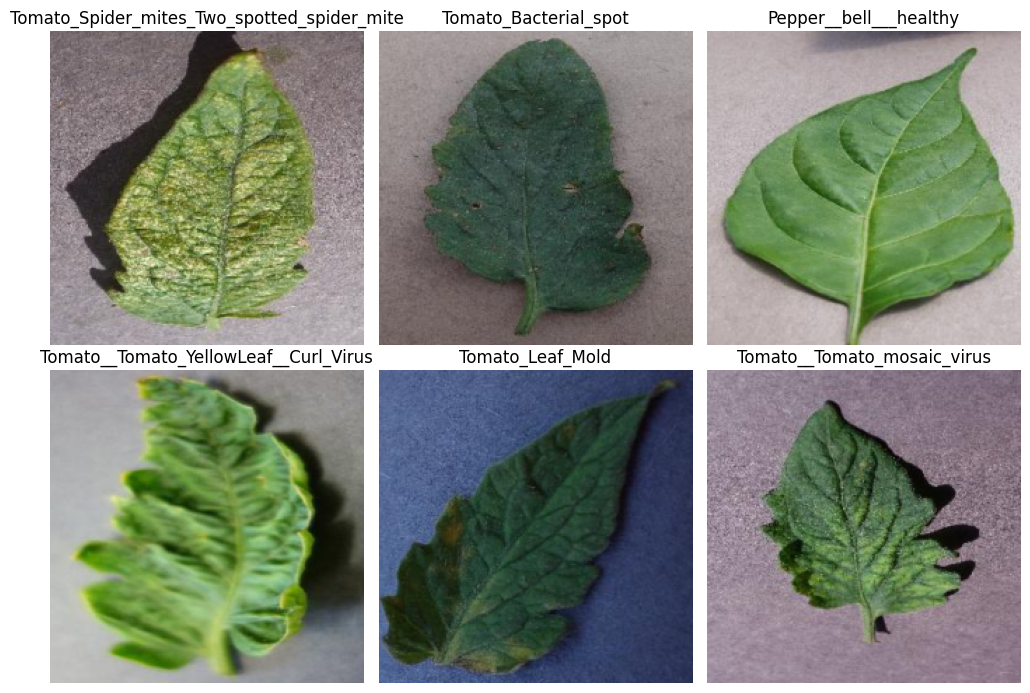

In [10]:
#Visualize Augmented images

import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2,3, figsize=(10,7))

for i, ax in enumerate(axes.flatten()):
    
    img = images[i].permute(1,2,0)

    img = img.numpy()

    img = img * [0.229,0.224,0.225] + [0.485,0.456,0.406]

    img = img.clip(0,1)

    ax.imshow(img)

    ax.set_title(
        class_names[labels[i]]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

14446
3095
3097


In [12]:
print(images.shape)

torch.Size([32, 3, 224, 224])
